# 04 — Flow Map & Movement Analysis
**Part 4 of 7** | GeoMetric Project

## Learning Objectives
- Visualise origin-destination flows with width-encoded lines
- Compute network centrality with NetworkX
- Identify hub-and-spoke structures in global airline routes

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
import warnings; warnings.filterwarnings("ignore")
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import networkx as nx
import folium
from scripts.utils.config import PATHS, STYLE, FLOW
from scripts.utils.map_utils import reproject_gdf, save_figure, add_map_annotations

In [2]:
world    = gpd.read_file(PATHS["processed"] / "master_world.gpkg")
airports = pd.read_csv(PATHS["processed"] / "airports_clean.csv")
routes   = pd.read_csv(PATHS["processed"] / "routes_clean.csv")
print(f"Routes: {len(routes):,} | Airports: {len(airports):,}")
routes.head(3)

Routes: 66,934 | Airports: 6,072


,airline,airline_id,src_iata,src_id,dst_iata,dst_id,codeshare,stops,equipment,src_lat,src_lon,dst_lat,dst_lon,src_country,dst_country
0,2B,410.0,AER,2965.0,KZN,2990.0,NaN,0,CR2,43.449902,39.956600,55.606201,49.278702,Russia,Russia
1,2B,410.0,ASF,2966.0,KZN,2990.0,NaN,0,CR2,46.283298,48.006302,55.606201,49.278702,Russia,Russia
2,2B,410.0,ASF,2966.0,MRV,2962.0,NaN,0,CR2,46.283298,48.006302,44.225101,43.081902,Russia,Russia


In [3]:
# ── Aggregate to country-pair flows ────────────────────────
r = routes.copy()
r = r[r["src_country"] != r["dst_country"]].dropna(subset=["src_country","dst_country"])
r["pair"] = r.apply(lambda x: tuple(sorted([x["src_country"], x["dst_country"]])), axis=1)
flows = r.groupby("pair").size().reset_index(name="num_routes")
flows[["country_a","country_b"]] = pd.DataFrame(flows["pair"].tolist(), index=flows.index)

ap_center = airports.groupby("country")[["lat","lon"]].mean()
for col, side in [("lat_a","country_a"),("lon_a","country_a"),("lat_b","country_b"),("lon_b","country_b")]:
    dim = col[-1]  # lat or lon
    flows[col] = flows[side].map(lambda c: ap_center.at[c, col[:-2]] if c in ap_center.index else np.nan)

flows = flows.dropna().sort_values("num_routes", ascending=False)
print(f"Country pairs: {len(flows):,}")
print(flows.head(10).to_string(index=False))

Country pairs: 2,316
                           pair  num_routes      country_a      country_b     lat_a       lon_a     lat_b       lon_b
        (Spain, United Kingdom)        1030          Spain United Kingdom 38.473286   -4.605081 53.254756   -2.335025
        (Mexico, United States)         742         Mexico  United States 22.713941 -101.271020 40.933284 -103.465931
        (Canada, United States)         727         Canada  United States 53.683225  -93.621849 40.933284 -103.465931
               (Germany, Spain)         707        Germany          Spain 51.375368    7.325457 38.473286   -4.605081
               (Germany, Italy)         442        Germany          Italy 51.375368    7.325457 42.247641   12.052676
(United Kingdom, United States)         410 United Kingdom  United States 53.254756   -2.335025 40.933284 -103.465931
                (China, Taiwan)         378          China         Taiwan 34.269642  110.199720 23.779339  120.487489
              (Germany, Greece)    

   Reprojected → robinson


   Saved: map_flow_routes.png  (300 DPI)


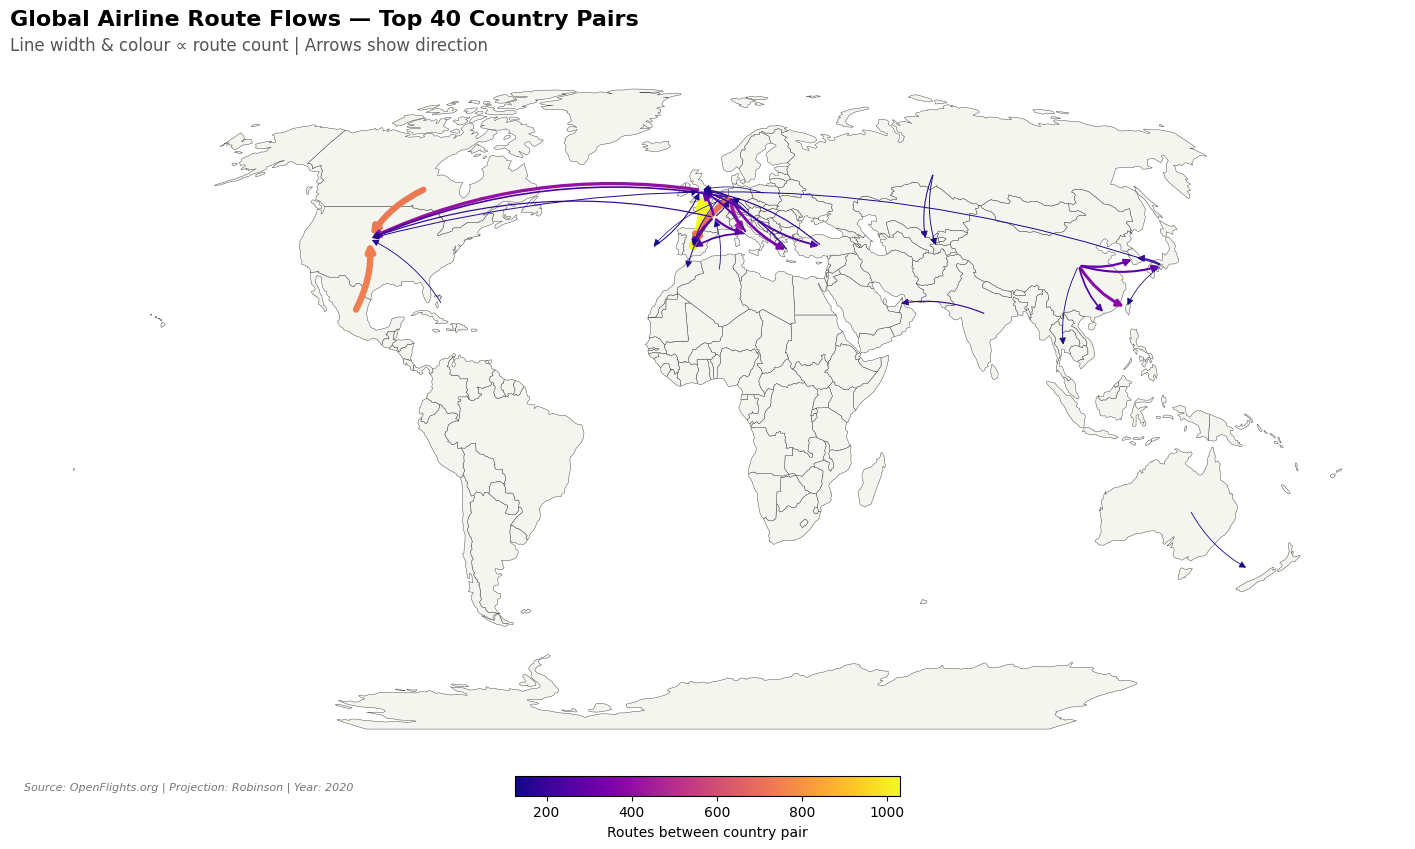

In [4]:
# ── Static flow map ────────────────────────────────────────
world_proj = reproject_gdf(world.copy(), "robinson")
top = flows.head(40)

import pyproj
transformer = pyproj.Transformer.from_crs("EPSG:4326", "+proj=robin", always_xy=True)

fig, ax = plt.subplots(figsize=(18, 10))
fig.patch.set_facecolor("white")
ax.set_facecolor(STYLE["ocean_color"])
world_proj.plot(ax=ax, color=STYLE["land_color"], linewidth=0.3, edgecolor=STYLE["boundary_color"])

vmin, vmax = top["num_routes"].min(), top["num_routes"].max()
cmap = cm.get_cmap("plasma")

for _, row in top.iterrows():
    try:
        xa, ya = transformer.transform(row["lon_a"], row["lat_a"])
        xb, yb = transformer.transform(row["lon_b"], row["lat_b"])
    except:
        continue
    norm = (row["num_routes"] - vmin) / (vmax - vmin + 1e-9)
    lw   = 0.5 + norm * 6
    ax.annotate("", xy=(xb,yb), xytext=(xa,ya),
                arrowprops=dict(arrowstyle="-|>", color=cmap(norm), lw=lw,
                                connectionstyle="arc3,rad=0.15", mutation_scale=10))

sm = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation="horizontal", pad=0.02, fraction=0.025, shrink=0.5)
cbar.set_label("Routes between country pair")
ax.set_axis_off()
add_map_annotations(ax, title="Global Airline Route Flows — Top 40 Country Pairs",
                    subtitle="Line width & colour ∝ route count | Arrows show direction",
                    source="OpenFlights.org", projection_name="robinson", year=2020)
save_figure(fig, PATHS["fig_part4"] / "map_flow_routes.png")
plt.show()

In [5]:
# ── NetworkX centrality analysis ───────────────────────────
G = nx.Graph()
for _, row in flows.head(100).iterrows():
    G.add_edge(row["country_a"], row["country_b"], weight=row["num_routes"])

degree   = pd.Series(dict(G.degree(weight="weight")), name="weighted_degree")
between  = pd.Series(nx.betweenness_centrality(G, weight="weight"), name="betweenness")
eigen    = pd.Series(nx.eigenvector_centrality(G, weight="weight", max_iter=500), name="eigenvector")

summary = pd.DataFrame([degree, between, eigen]).T.reset_index()
summary.columns = ["country","weighted_degree","betweenness","eigenvector"]
summary = summary.sort_values("weighted_degree", ascending=False).reset_index(drop=True)

summary.to_csv(PATHS["fig_part4"] / "network_summary_table.csv", index=False)

from IPython.display import display
display(summary.head(15).style.background_gradient(subset=["weighted_degree","betweenness"], cmap="YlOrRd"))

,country,weighted_degree,betweenness,eigenvector
0,United States,3745.000000,0.440950,0.318351
1,United Kingdom,3565.000000,0.144305,0.491291
2,Spain,3250.000000,0.145702,0.502837
3,Germany,3051.000000,0.094340,0.393835
4,France,1888.000000,0.055905,0.267920
5,Italy,1751.000000,0.211740,0.278814
6,China,1731.000000,0.245982,0.029233
7,Russia,955.000000,0.325646,0.032304
8,Canada,810.000000,0.000000,0.134272
9,Japan,782.000000,0.029350,0.031396


   Saved: network_graph.png  (300 DPI)


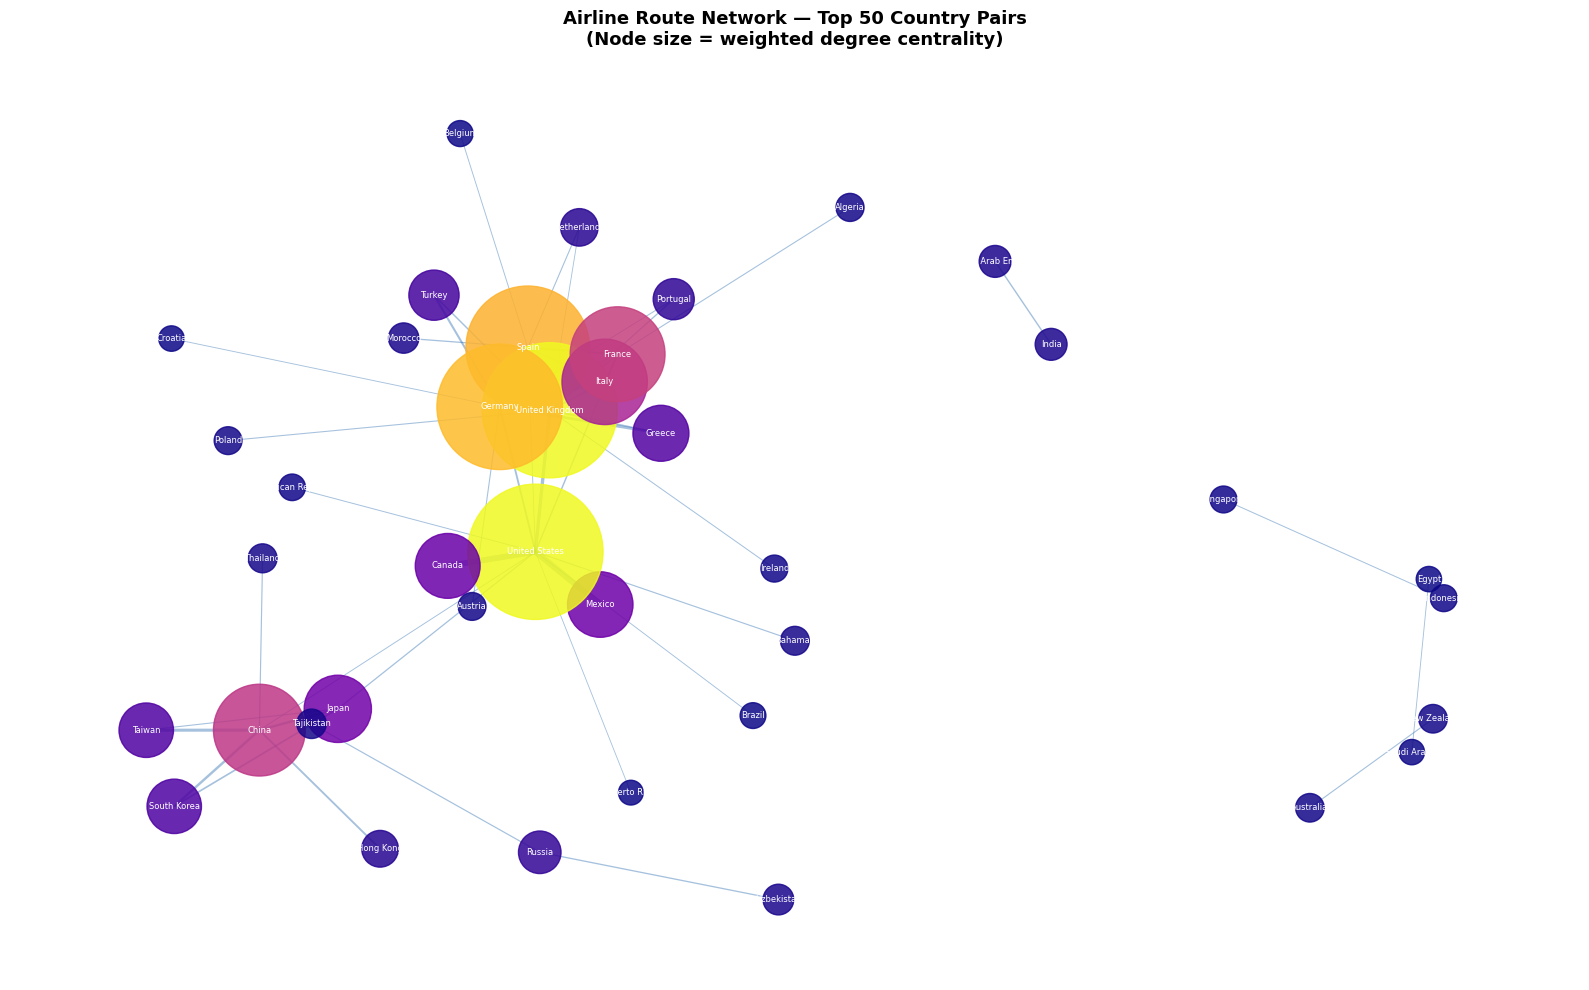

In [6]:
# ── Network graph visualisation ────────────────────────────
top50 = flows.head(50)
G50 = nx.Graph()
for _, row in top50.iterrows():
    G50.add_edge(row["country_a"], row["country_b"], weight=row["num_routes"])

degree_vals = dict(G50.degree(weight="weight"))
node_sizes  = [degree_vals.get(n, 1) * 3 for n in G50.nodes()]
edge_widths = [G50[u][v]["weight"] / top50["num_routes"].max() * 6 for u,v in G50.edges()]

fig, ax = plt.subplots(figsize=(16, 10))
pos = nx.spring_layout(G50, k=2.5, seed=42)
nx.draw_networkx_nodes(G50, pos, node_size=node_sizes, node_color=node_sizes,
                       cmap="plasma", alpha=0.85, ax=ax)
nx.draw_networkx_labels(G50, pos, font_size=6, font_color="white", ax=ax)
nx.draw_networkx_edges(G50, pos, width=edge_widths, alpha=0.4, edge_color="#2166ac", ax=ax)
ax.set_title("Airline Route Network — Top 50 Country Pairs\n(Node size = weighted degree centrality)",
             fontsize=13, fontweight="bold")
ax.axis("off")
plt.tight_layout()
save_figure(fig, PATHS["fig_part4"] / "network_graph.png")
plt.show()